C:\Users\Tannis\AppData\Local\Temp\ipykernel_9348\3945477574.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


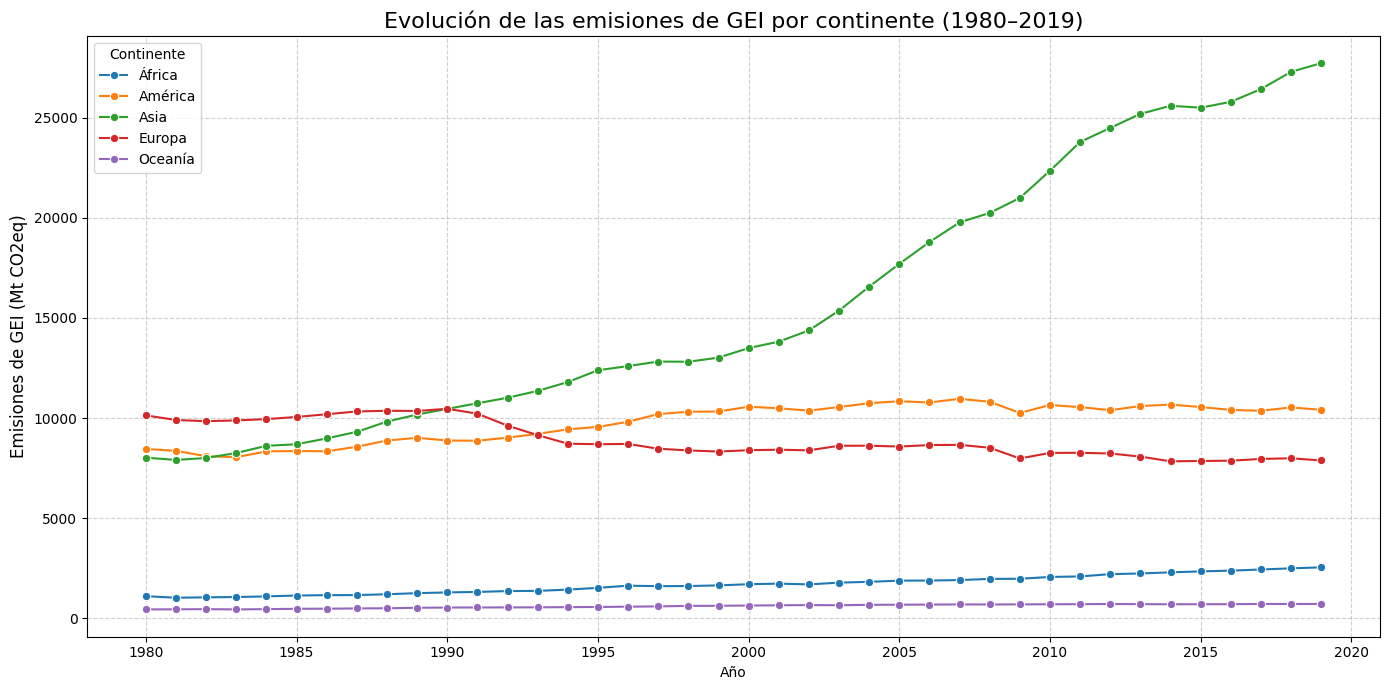

In [1]:
import os
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# ======================
# Conexión
# ======================
load_dotenv()
conn = pymysql.connect(
    host=os.getenv('DB_HOST'),
    user=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    database=os.getenv('DB_NAME')
)

# ======================
# Query
# ======================
query = """
SELECT 
    h.anio,
    c.nombre AS continente,
    SUM(h.valor) AS emisiones_totales
FROM hechos h
JOIN paises p      ON h.pais_id = p.codigo
JOIN continentes c ON p.continente_id = c.id
JOIN indicadores i ON h.indicador_id = i.id
WHERE i.codigo = 'emision_GEI'
  AND h.anio BETWEEN 1980 AND 2019
GROUP BY h.anio, c.nombre
ORDER BY h.anio, c.nombre;
"""

df = pd.read_sql(query, conn)

# ======================
# Gráfico
# ======================
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df,
    x="anio",
    y="emisiones_totales",
    hue="continente",
    marker="o"
)

plt.title("Evolución de las emisiones de GEI por continente (1980–2019)", fontsize=16)
plt.xlabel("Año")
plt.ylabel("Emisiones de GEI (Mt CO2eq)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Continente")
plt.tight_layout()
plt.show()


In [ ]:
# GEI total entre 1980 y 2019

query = """
SELECT 
    SUM(h.valor) AS emisiones_totales
FROM hechos h
WHERE h.indicador_id = 2
  AND h.anio BETWEEN 1980 AND 2019;
"""

df_result = pd.read_sql(query, conn)

print("Suma total de emisiones GEI (1980–2019):")
print(df_result.iloc[0, 0])

Suma total de emisiones GEI (1980–2019):
1472644.0853826557


C:\Users\Tannis\AppData\Local\Temp\ipykernel_9348\913009914.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_result = pd.read_sql(query, conn)


In [3]:
# PIB total entre 1980 y 2019

query = """
SELECT 
    SUM(h.valor) AS emisiones_totales
FROM hechos h
WHERE h.indicador_id = 3
  AND h.anio BETWEEN 1980 AND 2019;
"""

df_result = pd.read_sql(query, conn)

print("Suma total de PIB (1980–2019):")
print(df_result.iloc[0, 0])

Suma total de PIB (1980–2019):
3344235907100127.0


C:\Users\Tannis\AppData\Local\Temp\ipykernel_9348\987452426.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_result = pd.read_sql(query, conn)


C:\Users\Tannis\AppData\Local\Temp\ipykernel_9348\3100443442.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


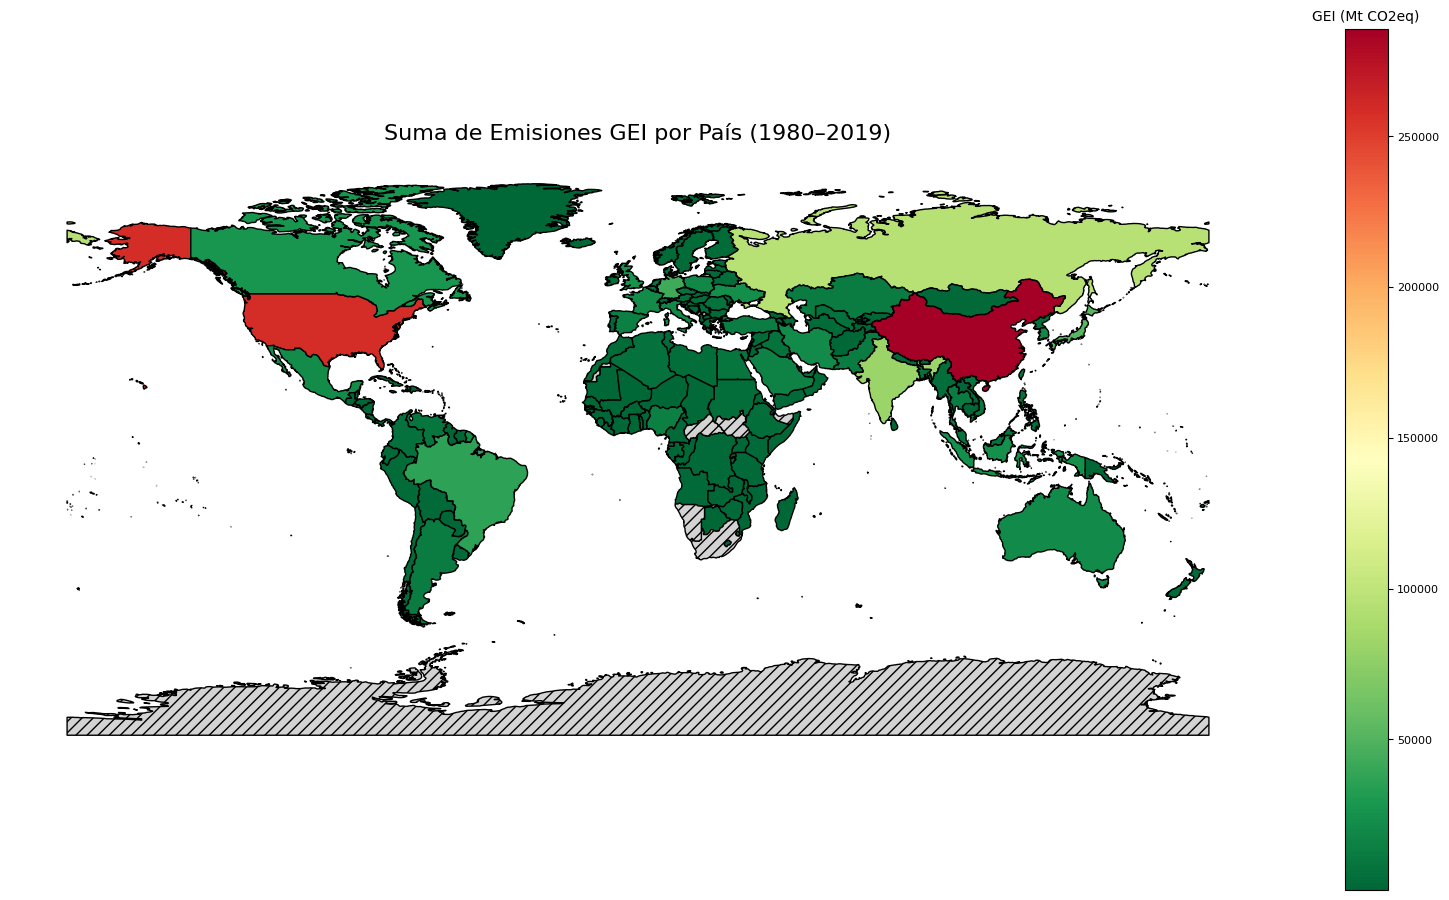

In [6]:
import os
import pandas as pd
import pymysql
import geopandas as gpd
import matplotlib.pyplot as plt
import pycountry
from dotenv import load_dotenv

# ======================
# Conexión
# ======================
load_dotenv()
conn = pymysql.connect(
    host=os.getenv('DB_HOST'),
    user=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    database=os.getenv('DB_NAME')
)

# ======================
# Query: emisiones GEI por país
# ======================
query = """
SELECT 
    p.codigo AS iso2,
    p.nombre AS pais,
    SUM(h.valor) AS emisiones_totales
FROM hechos h
JOIN paises p ON h.pais_id = p.codigo
WHERE h.indicador_id = 2
  AND h.anio BETWEEN 1980 AND 2019
GROUP BY p.codigo, p.nombre;
"""

df = pd.read_sql(query, conn)

# ======================
# ISO2 → ISO3 para merge con shapefile
# ======================
def iso2_to_iso3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None

df["iso_a3"] = df["iso2"].apply(iso2_to_iso3)
df = df.dropna(subset=["iso_a3"])

# ======================
# Cargar shapefile mundial
# ======================
SHAPEFILE = "./../../data/visualizacion/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp"
world = gpd.read_file(SHAPEFILE)

# Detectar columna ISO3 en shapefile
shape_key_candidates = ["ADM0_A3", "ISO_A3_EH", "ISO_A3"]
for k in shape_key_candidates:
    if k in world.columns:
        shape_key = k
        break
world[shape_key] = world[shape_key].astype(str).str.upper()

# ======================
# Merge
# ======================
map_data = world.merge(df, left_on=shape_key, right_on="iso_a3", how="left")

# ======================
# Plot
# ======================
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_title("Suma de Emisiones GEI por País (1980–2019)", fontsize=16, pad=12)

plot= map_data.plot(
    column="emisiones_totales",
    cmap="RdYlGn_r",   # verde = bajo, rojo = alto
    legend=True,
    ax=ax,
    edgecolor="black",
    missing_kwds={
        "color": "lightgrey",
        "hatch": "///",
        "label": "Sin datos"
    }
)


cbar = plot.get_figure().get_axes()[1] 
cbar.set_position([0.25, 0.1, 0.5, 0.02]) 
cbar.set_title("GEI (Mt CO2eq)", fontsize=10)
cbar.tick_params(labelsize=8)

ax.axis("off")
plt.tight_layout()
plt.show()


C:\Users\Tannis\AppData\Local\Temp\ipykernel_9348\1920135050.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pib = pd.read_sql(query, conn)


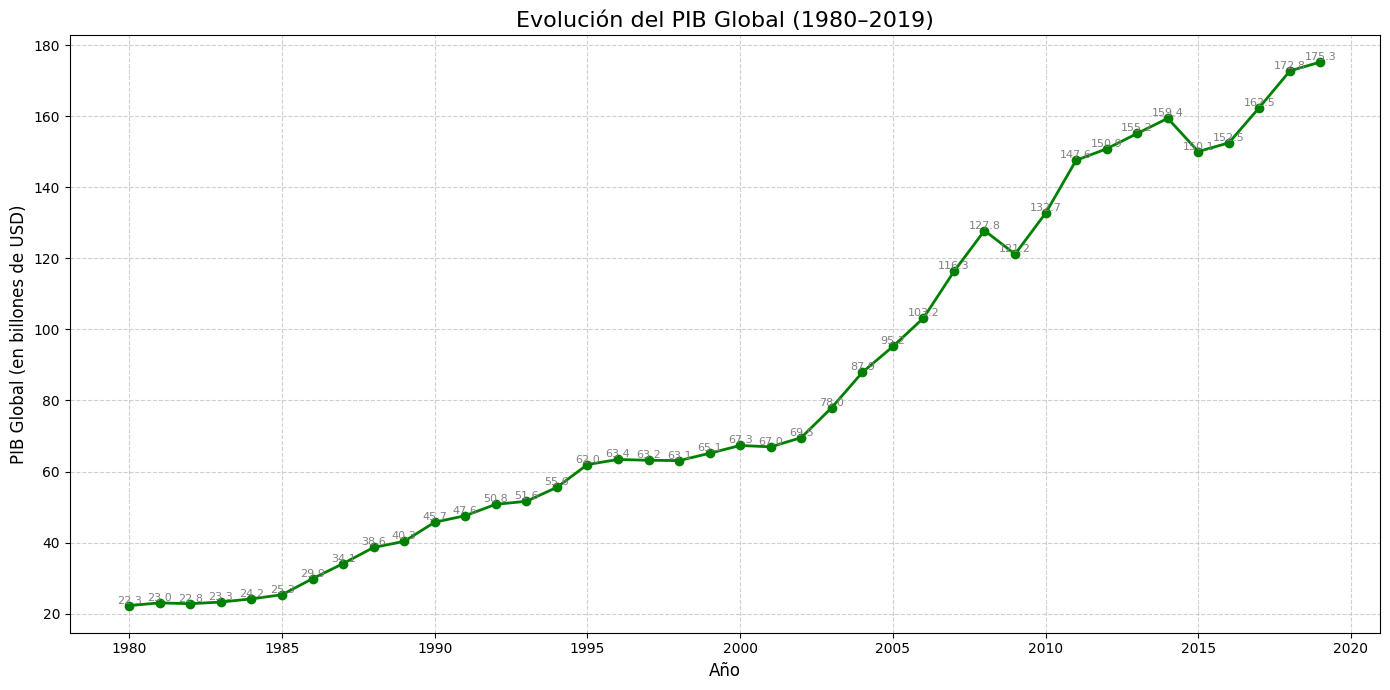

In [7]:
import os
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# ======================
# Conexión
# ======================
load_dotenv()
conn = pymysql.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

# ======================
# Query: PIB global (suma de todos los países)
# ======================
query = """
SELECT 
    h.anio,
    SUM(h.valor) AS pib_global
FROM hechos h
JOIN indicadores i ON h.indicador_id = i.id
WHERE i.codigo = 'NY.GDP.MKTP.CD'
  AND h.anio BETWEEN 1980 AND 2019
GROUP BY h.anio
ORDER BY h.anio;
"""

df_pib = pd.read_sql(query, conn)

# ======================
# Gráfico de evolución del PIB global
# ======================
plt.figure(figsize=(14, 7))
plt.plot(df_pib["anio"], df_pib["pib_global"] / 1e12, marker="o", linewidth=2, color="green")

plt.title("Evolución del PIB Global (1980–2019)", fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("PIB Global (en billones de USD)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

# Mostrar etiquetas encima de cada punto
for x, y in zip(df_pib["anio"], df_pib["pib_global"] / 1e12):
    plt.text(x, y, f"{y:.1f}", ha="center", va="bottom", fontsize=8, color="gray")

plt.tight_layout()
plt.show()


C:\Users\Tannis\AppData\Local\Temp\ipykernel_9348\862721144.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pib = pd.read_sql(query, conn)


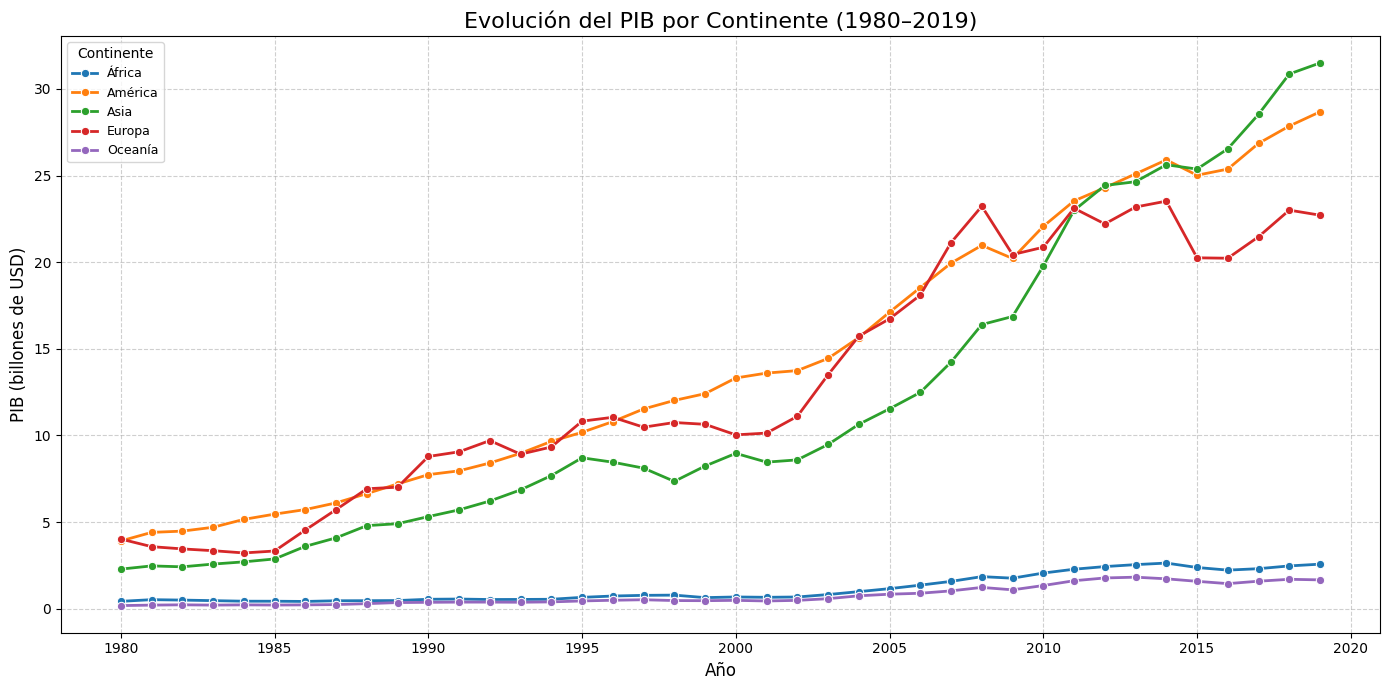

In [ ]:
import os
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# ======================
# Conexión
# ======================
load_dotenv()
conn = pymysql.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

# ======================
# Query: PIB por continente (excluyendo World)
# ======================
query = """
SELECT 
    h.anio,
    c.nombre AS continente,
    SUM(h.valor) AS pib_total
FROM hechos h
JOIN paises p      ON h.pais_id = p.codigo
JOIN continentes c ON p.continente_id = c.id
JOIN indicadores i ON h.indicador_id = i.id
WHERE i.codigo = 'NY.GDP.MKTP.CD'
  AND h.anio BETWEEN 1980 AND 2019
  AND c.nombre <> 'World'
GROUP BY h.anio, c.nombre
ORDER BY h.anio, c.nombre;
"""

df_pib = pd.read_sql(query, conn)

# ======================
# Gráfico PIB por continente (sin World)
# ======================
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=df_pib,
    x="anio",
    y=df_pib["pib_total"] / 1e12,  # convertir a billones de USD
    hue="continente",
    marker="o",
    linewidth=2
)

plt.title("Evolución del PIB por Continente (1980–2019)", fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("PIB (billones de USD)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Continente", fontsize=9)
plt.tight_layout()
plt.show()


In [11]:
import os
import pandas as pd
import pymysql
from dotenv import load_dotenv

# ======================
# Conexión
# ======================
load_dotenv()
conn = pymysql.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

# ======================
# Query PIB por continente (1980–2019, excluyendo World)
# ======================
query = """
SELECT 
    h.anio,
    c.nombre AS continente,
    SUM(h.valor) AS pib_total_usd
FROM hechos h
JOIN paises p      ON h.pais_id = p.codigo
JOIN continentes c ON p.continente_id = c.id
JOIN indicadores i ON h.indicador_id = i.id
WHERE i.codigo = 'NY.GDP.MKTP.CD'
  AND h.anio BETWEEN 1980 AND 2019
  AND c.nombre <> 'World'
GROUP BY h.anio, c.nombre
ORDER BY h.anio, c.nombre;
"""

df_pib = pd.read_sql(query, conn)

# Pivotear para ver una tabla clara: años en filas, continentes en columnas
tabla_pib = df_pib.pivot_table(
    index="anio",
    columns="continente",
    values="pib_total_usd",
    aggfunc="sum"
)

# Mostrar la tabla
print("Tabla de PIB anual por continente (USD):")
display(tabla_pib)


Tabla de PIB anual por continente (USD):


C:\Users\Tannis\AppData\Local\Temp\ipykernel_9348\4066907141.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pib = pd.read_sql(query, conn)


continente,América,Asia,Europa,Oceanía,África
anio,,,,,
1980,3.912800e+12,2.285133e+12,4.021183e+12,1.801074e+11,4.255399e+11
1981,4.405601e+12,2.471045e+12,3.582010e+12,2.078976e+11,5.221668e+11
1982,4.479265e+12,2.417859e+12,3.452501e+12,2.245610e+11,4.981658e+11
1983,4.700339e+12,2.576398e+12,3.348363e+12,2.080064e+11,4.655609e+11
1984,5.156693e+12,2.704486e+12,3.219126e+12,2.217193e+11,4.334068e+11
1985,5.459189e+12,2.872513e+12,3.330806e+12,2.118101e+11,4.324248e+11
1986,5.722810e+12,3.600325e+12,4.543441e+12,2.210653e+11,4.198303e+11
1987,6.108686e+12,4.090885e+12,5.720933e+12,2.390518e+11,4.590848e+11
1988,6.645641e+12,4.794999e+12,6.923551e+12,2.917124e+11,4.632341e+11


C:\Users\Tannis\AppData\Local\Temp\ipykernel_9348\3616968695.py:42: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emisiones = pd.read_sql(query, conn)


Correlación entre emisiones totales y población (1980–2019): 0.9779


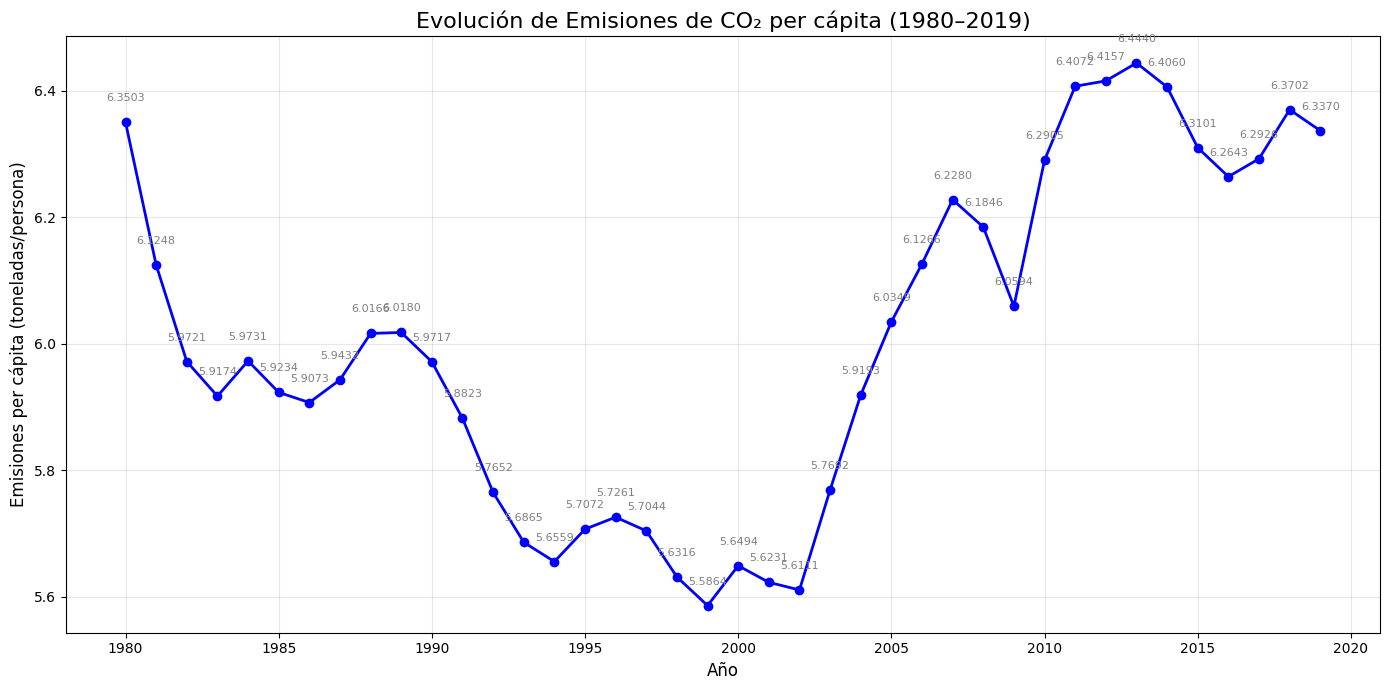

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# ======================
# 1. Leer archivo de población (Banco Mundial)
# ======================
file_path = r"C:\Users\Tannis\Desktop\codigo\TFM-Cambio-Climatico\data\fuentes\demograficos\API_SP.POP.TOTL_DS2_en_excel_v2_85347.xls"

# Generalmente los datos empiezan en la fila 4 -> usamos skiprows
df_pop = pd.read_excel(file_path, sheet_name="Data", skiprows=3)

# Filtrar solo el total mundial
df_pop_world = df_pop[df_pop["Country Name"] == "World"]

# Pasar de formato ancho a largo
df_pop_long = df_pop_world.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="anio",
    value_name="poblacion"
)

# Limpiar y dejar solo 1980–2019
df_pop_long["anio"] = pd.to_numeric(df_pop_long["anio"], errors="coerce")
df_pop_long = df_pop_long.dropna(subset=["anio"])
df_pop_long = df_pop_long[(df_pop_long["anio"] >= 1980) & (df_pop_long["anio"] <= 2019)]
df_pop_long = df_pop_long[["anio", "poblacion"]]

# ======================
# 2. Query de emisiones globales
# ======================
query = """
SELECT 
    anio,
    SUM(valor) AS emisiones_totales
FROM hechos
WHERE indicador_id = 2  -- id = emisiones GEI
  AND anio BETWEEN 1980 AND 2019
GROUP BY anio
ORDER BY anio;
"""

df_emisiones = pd.read_sql(query, conn)

# ======================
# 3. Unir emisiones con población
# ======================
df_comb = df_emisiones.merge(df_pop_long, on="anio", how="inner")

# Calcular emisiones per cápita
df_comb["emisiones_per_capita"] = df_comb["emisiones_totales"] / df_comb["poblacion"]

# 4. Calcular correlación
# =====================
corr = df_comb[["emisiones_totales", "poblacion"]].corr().iloc[0, 1]

print(f"Correlación entre emisiones totales y población (1980–2019): {corr:.4f}")

# Convertir emisiones a toneladas antes de dividir
df_comb["emisiones_per_capita"] = (df_comb["emisiones_totales"] * 1e6) / df_comb["poblacion"]

# ======================
# 4. Graficar
# ======================
plt.figure(figsize=(14, 7))
plt.plot(df_comb["anio"], df_comb["emisiones_per_capita"], marker="o", color="blue", linewidth=2)
plt.title("Evolución de Emisiones de CO₂ per cápita (1980–2019)", fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Emisiones per cápita (toneladas/persona)", fontsize=12)

# Añadir etiquetas con valores
for i, row in df_comb.iterrows():
    plt.text(
        row["anio"],
        row["emisiones_per_capita"] + 0.03,
        f"{row['emisiones_per_capita']:.4f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="gray"
    )

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\Tannis\AppData\Local\Temp\ipykernel_9348\550053429.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emisiones = pd.read_sql(query, conn)


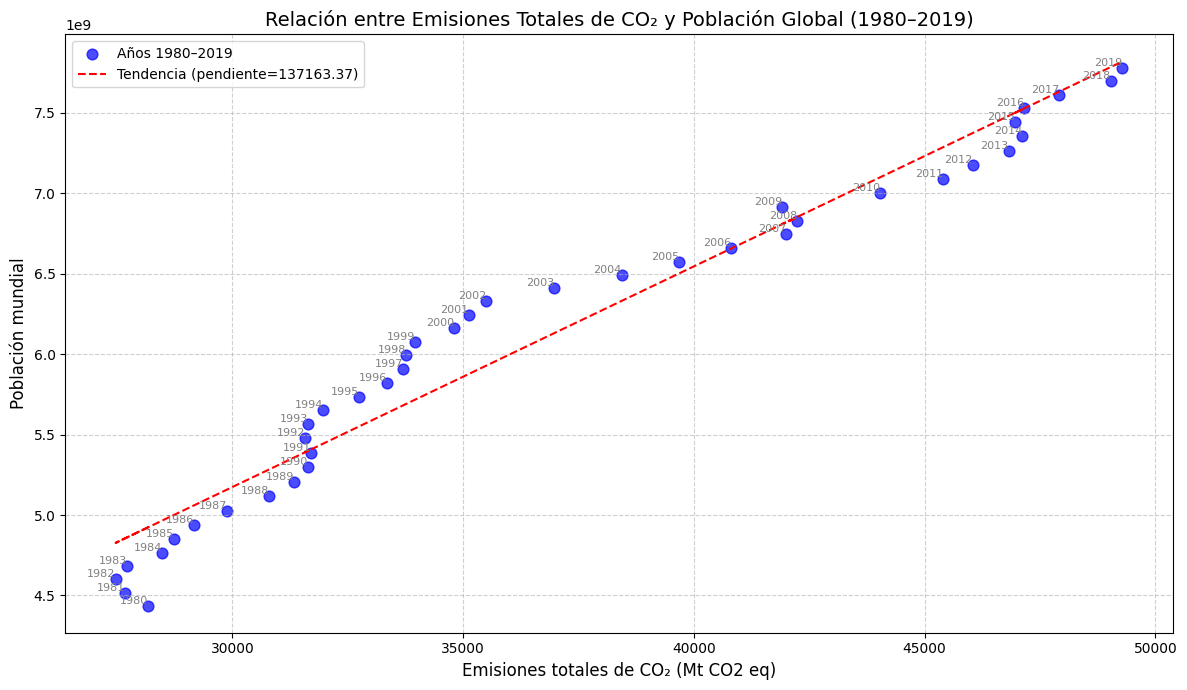

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ======================
# 1. Leer archivo de población (Banco Mundial)
# ======================
file_path = r"C:\Users\Tannis\Desktop\codigo\TFM-Cambio-Climatico\data\fuentes\demograficos\API_SP.POP.TOTL_DS2_en_excel_v2_85347.xls"

df_pop = pd.read_excel(file_path, sheet_name="Data", skiprows=3)

df_pop_world = df_pop[df_pop["Country Name"] == "World"]

df_pop_long = df_pop_world.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="anio",
    value_name="poblacion"
)

df_pop_long["anio"] = pd.to_numeric(df_pop_long["anio"], errors="coerce")
df_pop_long = df_pop_long.dropna(subset=["anio"])
df_pop_long = df_pop_long[(df_pop_long["anio"] >= 1980) & (df_pop_long["anio"] <= 2019)]
df_pop_long = df_pop_long[["anio", "poblacion"]]

# ======================
# 2. Query de emisiones globales
# ======================
query = """
SELECT 
    anio,
    SUM(valor) AS emisiones_totales
FROM hechos
WHERE indicador_id = 2
  AND anio BETWEEN 1980 AND 2019
GROUP BY anio
ORDER BY anio;
"""
df_emisiones = pd.read_sql(query, conn)

# ======================
# 3. Unir datos
# ======================
df_comb = df_emisiones.merge(df_pop_long, on="anio", how="inner")

# ======================
# 4. Gráfico de dispersión
# ======================
plt.figure(figsize=(12, 7))
plt.scatter(df_comb["emisiones_totales"], df_comb["poblacion"], c="blue", s=60, alpha=0.7, label="Años 1980–2019")

# Etiquetar cada punto con el año
for i, row in df_comb.iterrows():
    plt.text(row["emisiones_totales"], row["poblacion"], str(int(row["anio"])),
             fontsize=8, ha="right", va="bottom", color="gray")

# Línea de tendencia
z = np.polyfit(df_comb["emisiones_totales"], df_comb["poblacion"], 1)
p = np.poly1d(z)
plt.plot(df_comb["emisiones_totales"], p(df_comb["emisiones_totales"]), "r--", label=f"Tendencia (pendiente={z[0]:.2f})")

plt.title("Relación entre Emisiones Totales de CO₂ y Población Global (1980–2019)", fontsize=14)
plt.xlabel("Emisiones totales de CO₂ (Mt CO2 eq)", fontsize=12)
plt.ylabel("Población mundial", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [34]:
# Filtrar solo 2019
data_2019 = df_comb[df_comb["anio"] == 2019]

# Calcular emisiones per cápita
if not data_2019.empty:
    emisiones_2019 = data_2019["emisiones_totales"].values[0]
    poblacion_2019 = data_2019["poblacion"].values[0]
    per_capita_2019 = emisiones_2019 / poblacion_2019
    print(f"Emisiones per cápita en 2019: {per_capita_2019:.4f} toneladas/persona")
else:
    print("No hay datos disponibles para 2019.")


Emisiones per cápita en 2019: 0.0000 toneladas/persona


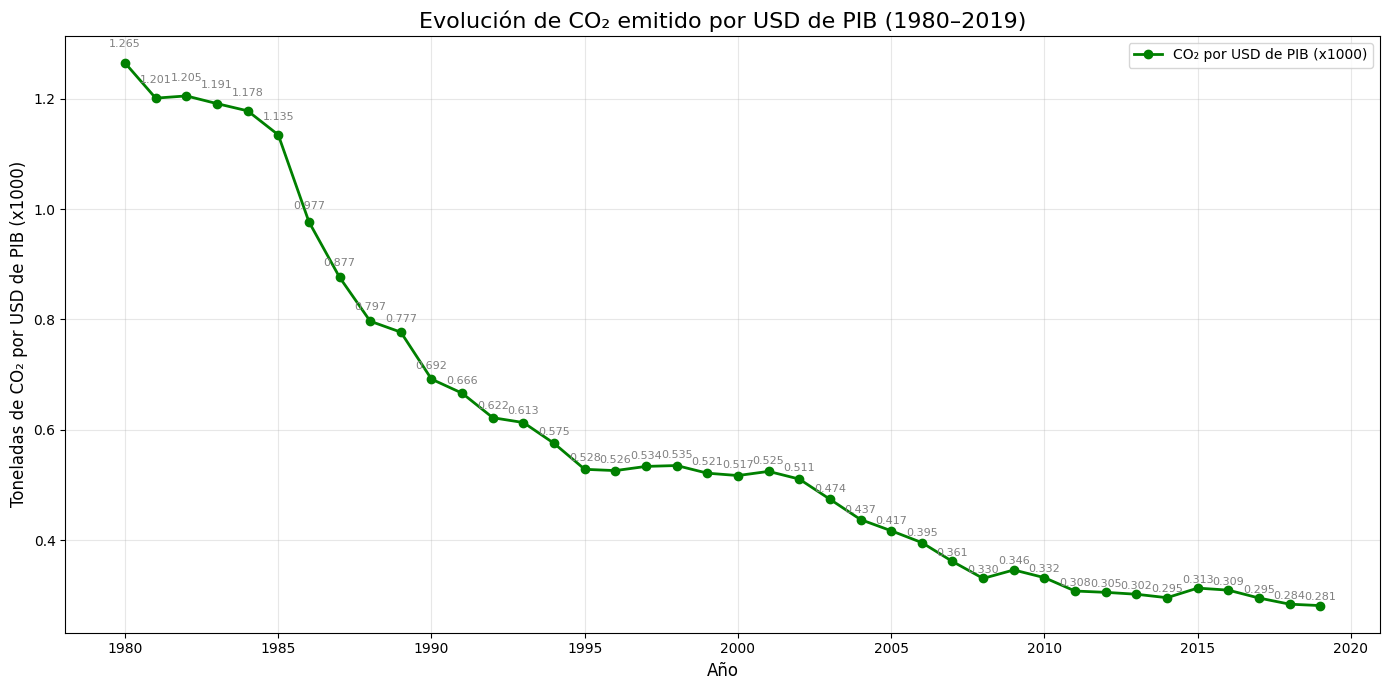

In [47]:
import matplotlib.pyplot as plt

# Multiplicar la serie por 1000
df_ratio["co2_por_usd_pib_mil"] = df_ratio["co2_por_usd_pib"] * 1000

# ======================
# Graficar
# ======================
plt.figure(figsize=(14, 7))
plt.plot(
    df_ratio["anio"],
    df_ratio["co2_por_usd_pib_mil"],
    marker="o",
    color="green",
    linewidth=2,
    label="CO₂ por USD de PIB (x1000)"
)

# Etiquetas encima de cada punto
for i, row in df_ratio.iterrows():
    plt.text(
        row["anio"],
        row["co2_por_usd_pib_mil"] + (row["co2_por_usd_pib_mil"] * 0.02),
        f"{row['co2_por_usd_pib_mil']:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="gray"
    )

plt.title("Evolución de CO₂ emitido por USD de PIB (1980–2019)", fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Toneladas de CO₂ por USD de PIB (x1000)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()



C:\Users\Tannis\AppData\Local\Temp\ipykernel_9348\4245079500.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cont = pd.read_sql(query, conn)
C:\Users\Tannis\AppData\Local\Temp\ipykernel_9348\4245079500.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


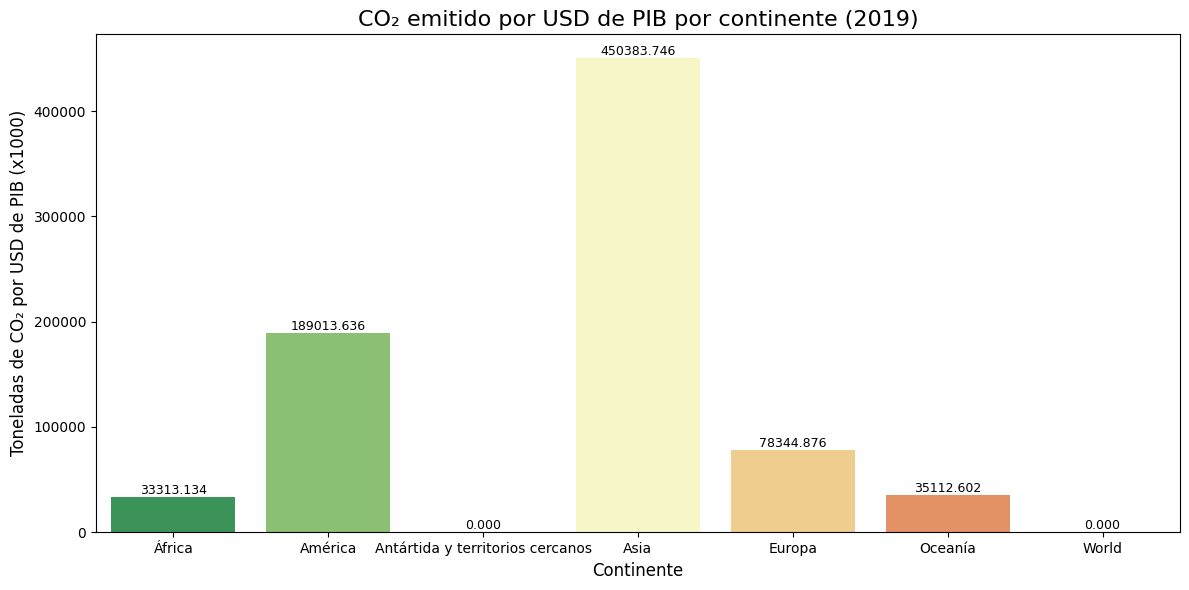

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymysql
import os
from dotenv import load_dotenv

# ======================
# Conexión
# ======================
load_dotenv()
conn = pymysql.connect(
    host=os.getenv('DB_HOST'),
    user=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    database=os.getenv('DB_NAME')
)

# ======================
# Query: emisiones y PIB por continente (2019)
# ======================
query = """
SELECT 
    c.nombre AS continente,
    SUM(CASE WHEN h.indicador_id = 2 THEN h.valor ELSE 0 END) AS emisiones,
    SUM(CASE WHEN h.indicador_id = 1 THEN h.valor ELSE 0 END) AS pib
FROM hechos h
JOIN paises p ON h.pais_id = p.codigo
JOIN continentes c ON p.continente_id = c.id
WHERE h.anio = 2019
  AND h.indicador_id IN (1, 2)  -- 1 = PIB, 2 = Emisiones GEI
GROUP BY c.nombre
ORDER BY c.nombre;
"""

df_cont = pd.read_sql(query, conn)

# ======================
# Calcular CO₂ por USD de PIB
# ======================
df_cont["co2_por_usd_pib"] = df_cont["emisiones"] / df_cont["pib"] * 1000  # multiplicado x1000 para escala

# ======================
# Graficar
# ======================
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_cont,
    x="continente",
    y="co2_por_usd_pib",
    palette="RdYlGn_r"
)

# Títulos y ejes
plt.title("CO₂ emitido por USD de PIB por continente (2019)", fontsize=16)
plt.xlabel("Continente", fontsize=12)
plt.ylabel("Toneladas de CO₂ por USD de PIB (x1000)", fontsize=12)

# Etiquetas sobre las barras
for i, row in df_cont.iterrows():
    plt.text(i, row["co2_por_usd_pib"] + 0.01, f"{row['co2_por_usd_pib']:.3f}",
             ha="center", va="bottom", fontsize=9, color="black")

plt.tight_layout()
plt.show()
